# Prepara y estructura datos con Python III 🐍🖥️✍️

## Objetivos academicos

- Realizar resúmenes agregados con datos
- Combinar datos entre sí
- Usar gráficos para resumir la información 


## Pandas para análisis de datos 🐼📊

---

### Resumen de las sesiones anteriores 🔃

Trabajaremos con dos datasets: **openaq_pm25**, que contiene niveles de contaminación atmosférica por país, e **IHME_GBD_2021**, con indicadores de salud global. Usaremos ambos para practicar el resumen de datos con pandas y la unión de tablas mediante claves comunes.


En sesiones anteriores hemos trabajado con pandas 🐼:

- Carga de datos
- Exploración de datos
- Limpieza de datos
    - Conversión de variables
    - Limpieza de nulos y duplicados
 




In [48]:
import pandas as pd  # ¿Pa' qué servia esto?

#### *Carga los datos*

In [85]:
pm25=pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/openaq_pm25.csv')


In [50]:
gbd=pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/IHME_GBD_2021.csv')

In [51]:
pm25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   X                7240 non-null   float64
 1   Y                7240 non-null   float64
 2   OBJECTID         7240 non-null   int64  
 3   location_id      7240 non-null   int64  
 4   city             7237 non-null   object 
 5   location         7237 non-null   object 
 6   lastUpdated      7231 non-null   object 
 7   parameter        7240 non-null   object 
 8   unit             7240 non-null   object 
 9   value            7225 non-null   float64
 10  value_2          0 non-null      float64
 11  unit_2           7237 non-null   object 
 12  owner_name       7240 non-null   object 
 13  provider_name    7236 non-null   object 
 14  instrument_name  7017 non-null   object 
 15  url              7240 non-null   object 
 16  country_name     7240 non-null   object 
 17  country_id    

In [52]:
gbd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335232 entries, 0 to 335231
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   measure_id      335232 non-null  int64  
 1   measure_name    335232 non-null  object 
 2   location_id     335232 non-null  int64  
 3   location_name   335232 non-null  object 
 4   country_id      331776 non-null  object 
 5   sex_id          335232 non-null  int64  
 6   sex_name        335232 non-null  object 
 7   age_group_id    335232 non-null  int64  
 8   age_group_name  335232 non-null  object 
 9   year_id         335232 non-null  int64  
 10  rei_id          335232 non-null  int64  
 11  pathogen        335232 non-null  object 
 12  metric_id       335232 non-null  int64  
 13  metric          335232 non-null  object 
 14  value           335214 non-null  float64
 15  lower           335232 non-null  float64
 16  upper           335232 non-null  float64
dtypes: float64

#### Limpieza de  *pm25*

In [86]:
pm25['country_name'] = pm25['country_name'].str.title()
pm25['lastUpdated'] = pd.to_datetime(pm25['lastUpdated'],errors='coerce')
pm25['year_id'] = pm25['lastUpdated'].dt.year


In [87]:
pm25 = pm25[['parameter',	'unit',	'value', 'country_name', 'lastUpdated','year_id']]

In [88]:
pm25 = pm25[pm25['country_name'].isin(['Argentina', 'Brazil', 'Costa Rica','Mexico','Chile'])]


In [89]:
pm25= pm25.dropna()
pm25 = pm25.drop_duplicates()



In [57]:

pm25.info(),pm25.head()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 29 to 7159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   parameter     147 non-null    object             
 1   unit          147 non-null    object             
 2   value         147 non-null    float64            
 3   country_name  147 non-null    object             
 4   lastUpdated   147 non-null    datetime64[ns, UTC]
 5   year_id       147 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(2), object(3)
memory usage: 8.0+ KB


(None,
    parameter   unit    value country_name               lastUpdated  year_id
 29      pm25  µg/m³  4756.54       Mexico 2021-10-01 15:05:04+00:00   2021.0
 30      pm25  µg/m³  4704.83       Mexico 2021-10-01 15:05:44+00:00   2021.0
 34      pm25  µg/m³  3137.26       Mexico 2021-09-07 14:00:31+00:00   2021.0
 37      pm25  µg/m³  2947.71       Mexico 2021-10-01 15:05:02+00:00   2021.0
 54      pm25  µg/m³   987.17       Mexico 2021-10-01 13:00:00+00:00   2021.0)

#### Limpieza de  *gbd*

In [58]:
gbd = gbd.rename(columns={'location_name': 'country_name'})

In [59]:
gbd['country_name'] = gbd['country_name'].str.title()

In [60]:
gbd = gbd[['country_name', 'year_id', 'pathogen', 'metric', 'measure_name', 'age_group_name']]

In [61]:
gbd = gbd[gbd['country_name'].isin(['Argentina', 'Brazil', 'Costa Rica','Mexico'])]

In [62]:
gbd = gbd[gbd['measure_name'] == 'Deaths']


In [63]:
gbd = gbd[gbd['pathogen'] == 'Influenza']


In [64]:
gbd = gbd[gbd['age_group_name'] == 'All Ages']

In [65]:
gbd = gbd[gbd['metric'] == 'Percent']


In [66]:
gbd = gbd[gbd['year_id'] == 2021]


In [67]:
gbd.info(),gbd.head()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 253063 to 255895
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   country_name    4 non-null      object
 1   year_id         4 non-null      int64 
 2   pathogen        4 non-null      object
 3   metric          4 non-null      object
 4   measure_name    4 non-null      object
 5   age_group_name  4 non-null      object
dtypes: int64(1), object(5)
memory usage: 224.0+ bytes


(None,
        country_name  year_id   pathogen   metric measure_name age_group_name
 253063    Argentina     2021  Influenza  Percent       Deaths       All Ages
 253615   Costa Rica     2021  Influenza  Percent       Deaths       All Ages
 255871       Mexico     2021  Influenza  Percent       Deaths       All Ages
 255895       Brazil     2021  Influenza  Percent       Deaths       All Ages)

### Resumir datos (`group by`+ `agg`)


Para resumir valores de una columna usamos sintaxis como `df["col"].mean()` o `df["col"].min()`, obteniendo métricas rápidas sin agrupar datos.


In [68]:
df_ar = pm25[pm25["country_name"] == "Argentina"]
df_mx = pm25[pm25["country_name"] == "Mexico"]

In [69]:
# Métricas Argentina
mean_ar = df_ar["value"].mean()
median_ar = df_ar["value"].median()
min_ar = df_ar["value"].min()
max_ar = df_ar["value"].max()
std_ar = df_ar["value"].std()

In [70]:
print("Argentina:   Media:", mean_ar, "Mediana:",median_ar, " Min-Max:", min_ar,"-",max_ar, " Desv. est:", std_ar)

Argentina:   Media: 4.1928128283333335 Mediana: 3.781230162  Min-Max: 2.59 - 6.207208323  Desv. est: 1.8433934011530635


In [71]:
# Métricas México
mean_mx = df_mx["value"].mean()
median_mx = df_mx["value"].median()
min_mx = df_mx["value"].min()
max_mx = df_mx["value"].max()
std_mx = df_mx["value"].std()

In [72]:
print("México:   Media:", mean_mx, "Mediana:",median_mx, " Min-Max:", min_mx,"-",max_mx, " Desv. est:", std_mx)

México:   Media: 193.60033999621277 Mediana: 16.564999999999998  Min-Max: 0.0 - 4756.54  Desv. est: 808.4632258045135


El método `groupby()` en pandas permite agrupar datos por una columna y calcular métricas sobre cada grupo. Su sintaxis básica es: `df.groupby("col")["valor"].mean()`. Puedes usar funciones de agregación como `mean()`, `median()`, `min()`, `max()`, `std()`, `count()` o combinarlas con `.agg()` para calcular varias métricas a la vez: `df.groupby("col")["valor"].agg(["mean","min","max"])`. 

In [73]:
pm25.groupby('country_name')['value'].mean()

country_name
Argentina       4.192813
Brazil         10.275783
Chile          22.777396
Costa Rica      5.760000
Mexico        193.600340
Name: value, dtype: float64

El resultado de `groupby()` genera un índice basado en la columna agrupada, por eso usamos `reset_index()` para convertirlo nuevamente en una columna normal y obtener un DataFrame limpio y fácil de manipular.

In [74]:
pm25.groupby('country_name')['value'].mean().reset_index()

,country_name,value
0,Argentina,4.192813
1,Brazil,10.275783
2,Chile,22.777396
3,Costa Rica,5.760000
4,Mexico,193.600340


In [75]:
pm25.groupby('country_name')['value'].agg(["mean", "sum", "count"]).reset_index()

,country_name,mean,sum,count
0,Argentina,4.192813,12.578438,3
1,Brazil,10.275783,123.309394,12
2,Chile,22.777396,842.763643,37
3,Costa Rica,5.760000,5.760000,1
4,Mexico,193.600340,18198.431960,94


In [76]:
group_cols = ['parameter', 'unit', 'country_name', 'year_id']
pm25_agg = pm25.groupby(group_cols, dropna=False)['value'].mean().reset_index()
pm25_agg

,parameter,unit,country_name,year_id,value
0,pm25,µg/m³,Argentina,2021.0,4.192813
1,pm25,µg/m³,Brazil,2021.0,10.275783
2,pm25,µg/m³,Chile,2021.0,22.777396
3,pm25,µg/m³,Costa Rica,2021.0,5.760000
4,pm25,µg/m³,Mexico,2021.0,193.600340


### Unir datos (`merge`)

El método `merge()` permite unir dos DataFrames usando una columna en común. Su sintaxis básica es: `df_a.merge(df_b, how="left", left_on="id", right_on="id")`, donde `how` define el tipo de unión y las claves indican qué columnas se usarán para combinar los datos.


In [34]:
df_a=pd.DataFrame({'id':[1,2,3,4],'value':[15,15,87,78]})
df_b=pd.DataFrame({'id':[1,3,5],'tag':['a','b','c']})
df_a,df_b


(   id  value
 0   1     15
 1   2     15
 2   3     87
 3   4     78,
    id tag
 0   1   a
 1   3   b
 2   5   c)

En `merge()`, una unión **left** conserva todas las filas del DataFrame izquierdo y solo agrega coincidencias del derecho. En cambio, una unión **inner** solo devuelve las filas donde ambas tablas tienen coincidencias en la clave de unión.


In [36]:
df_a.merge(df_b,how='left',left_on='id',right_on='id')

,id,value,tag
0,1,15,a
1,2,15,NaN
2,3,87,b
3,4,78,NaN


In [37]:
df_a.merge(df_b,how='inner',left_on='id',right_on='id')

,id,value,tag
0,1,15,a
1,3,87,b


In [93]:
merged= pm25_agg.merge( gbd, on=['country_name', 'year_id'], how='inner')
merged

,parameter,unit,country_name,year_id,value,pathogen,metric,measure_name,age_group_name
0,pm25,µg/m³,Argentina,2021.0,4.192813,Influenza,Percent,Deaths,All Ages
1,pm25,µg/m³,Brazil,2021.0,10.275783,Influenza,Percent,Deaths,All Ages
2,pm25,µg/m³,Costa Rica,2021.0,5.760000,Influenza,Percent,Deaths,All Ages
3,pm25,µg/m³,Mexico,2021.0,193.600340,Influenza,Percent,Deaths,All Ages


### Herramientas visuales

Para visualizar datos podemos usar **matplotlib** y **seaborn**, dos librerías muy comunes en análisis de datos. Con comandos como `df['col'].value_counts().plot(kind='bar')` generamos gráficos rápidos y personalizados. Luego usamos `plt.title()`, `plt.ylabel()` y `plt.show()` para ajustar y mostrar la gráfica.


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

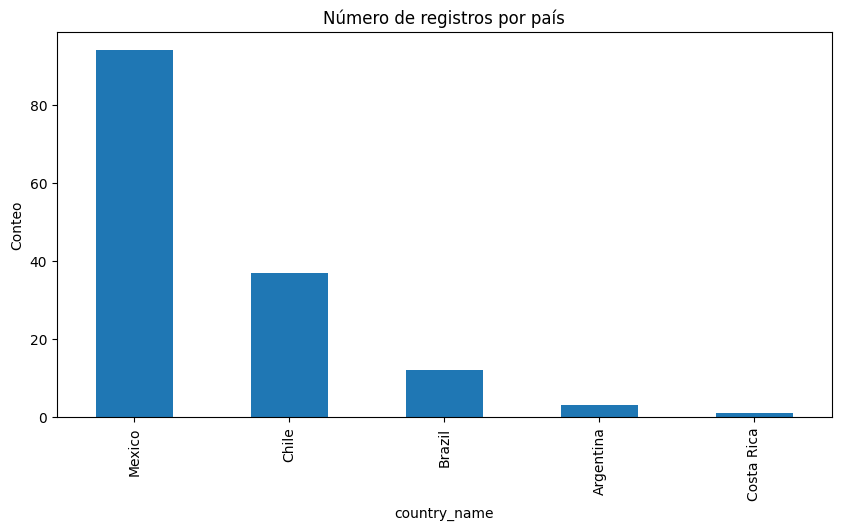

In [80]:
pm25['country_name'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Número de registros por país')
plt.ylabel('Conteo')
plt.show()

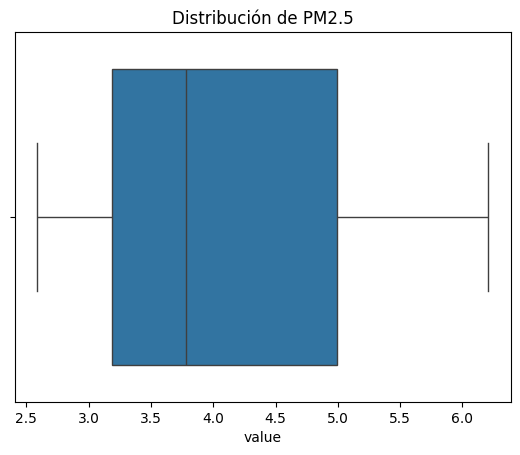

In [83]:
sns.boxplot(data=pm25[pm25['country_name']=='Argentina'], x='value')
plt.title('Distribución de PM2.5')
plt.show()

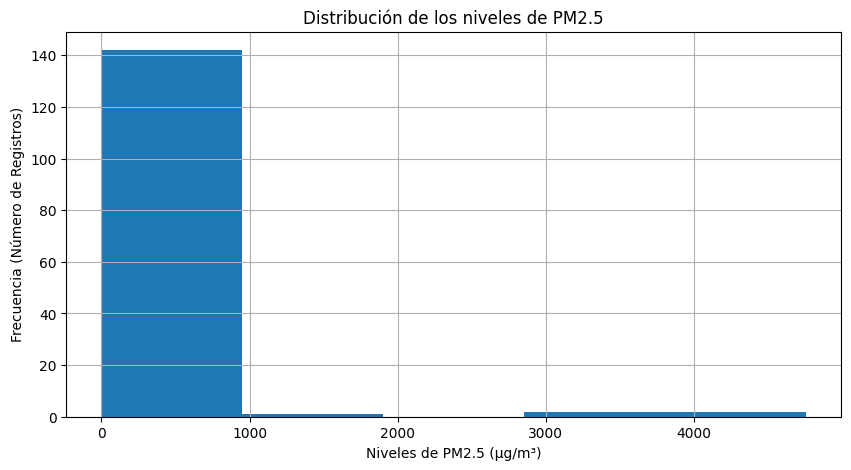

In [ ]:
pm25['value'].hist(bins=5, figsize=(10, 5))
plt.title('Distribución de los niveles de PM2.5')
plt.xlabel('Niveles de PM2.5 (µg/m³)')
plt.ylabel('Frecuencia (Número de Registros)')
plt.show()

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta  nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [`Discord`](https://discord.com/channels/1081207584104656986/1420849538196836472).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal [`#project`](https://discord.com/channels/1081207584104656986/1420848813186351134) para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
    - En tus preguntas recuerda etiquetar a `@Dataconsulta` y ubica tu pregunta de acuerdo a `Sprint/Capitulo/Seccion`
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨